# Student Dropout and Academic Success Prediction

## AAI-510: Machine Learning for Artificial Intelligence Final Project

This notebook follows the requested project structure end to end:

- Problem statement and data set finalization
- Initial EDA and cleaning with graphical and non-graphical relationship analysis
- Data preparation, feature engineering, scaling, and class imbalance handling
- Feature selection rationale based on EDA and model-based importance
- Modeling with logistic regression, random forest, XGBoost, LightGBM, and a stacking ensemble
- Evaluation and model comparisons
- Explainability with SHAP
- Deployment discussion, including the FastAPI service and Streamlit application
- Discussion, conclusions, and recommendations

## Submission Information

- GitHub code repository: https://github.com/University-San-Diego-MAAI/student-dropout-academic-success
- Submission filename requirement: rename this notebook to `Final Project Section#-Team #.ipynb` using the actual course section and team number before upload.
- Access note: confirm the instructor(s) have access to the GitHub repository before final submission.



In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/manojpatra/Documents/USD-APPLIEDAI-2025/AAI-510 - Machine Learning Fundamentals and Applications/student-dropout-academic-success


---

## 1. Problem Statement and Data Set Finalization

The goal is to predict whether a student will **Dropout**, remain **Enrolled**, or **Graduate** using demographic, socioeconomic, admission, academic performance, and macroeconomic variables from the UCI Student Dropout and Academic Success dataset.

This is a multiclass classification problem, but the most urgent operational use case is early identification of students at high risk of dropout. The proposed approach therefore uses interpretable baseline models and stronger tree-based ensemble models, evaluates them with macro-F1 to avoid over-favoring the majority class, and exposes the selected model through an API and Streamlit advising application.

The finalized data source is the UCI dataset ID 697. The project loader caches the source features and targets under `data/raw/` so repeated notebook and training runs use the same finalized dataset.


In [2]:
from dropout.data.loader import load_dataset

df = load_dataset(PROJECT_ROOT / "data" / "raw")
target_order = ["Dropout", "Enrolled", "Graduate"]

print(f"Dataset shape: {df.shape}")
print(f"Predictor columns: {df.shape[1] - 1}")
print(f"Response variable: target")
display(df.head())

target_summary = df["target"].value_counts().reindex(target_order).rename("count").to_frame()
target_summary["percent"] = (target_summary["count"] / len(df) * 100).round(2)
display(target_summary)


Dataset shape: (4424, 37)
Predictor columns: 36
Response variable: target


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


,count,percent
target,,
Dropout,1421,32.12
Enrolled,794,17.95
Graduate,2209,49.93


---

## 2. Data Understanding (EDA)

This section combines non-graphical summaries and graphical EDA to understand how the response variable relates to predictor variables. The main questions are:

- Are the classes imbalanced?
- Which academic, financial, and demographic variables show separation by outcome?
- Are there missing values, duplicate records, or unusual values that need cleaning?


In [3]:
data_quality = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(),
    }
)

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Total missing values: {int(df.isna().sum().sum())}")
display(data_quality)


Duplicate rows: 0
Total missing values: 0


,dtype,missing_count,missing_pct,unique_values
Marital Status,int64,0,0.0,6
Application mode,int64,0,0.0,18
Application order,int64,0,0.0,8
Course,int64,0,0.0,17
Daytime/evening attendance,int64,0,0.0,2
Previous qualification,int64,0,0.0,17
Previous qualification (grade),float64,0,0.0,101
Nacionality,int64,0,0.0,21
Mother's qualification,int64,0,0.0,29
Father's qualification,int64,0,0.0,34


### 2.1 Non-Graphical Relationship Analysis

The table below compares key numeric predictors by target class. These group-level summaries provide a direct non-graphical view of the relationship between student outcomes and predictors before model training.


In [4]:
key_numeric = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]
key_numeric = [c for c in key_numeric if c in df.columns]

relationship_summary = df.groupby("target")[key_numeric].agg(["mean", "median", "std"]).round(2)
display(relationship_summary)

for col in ["Debtor", "Tuition fees up to date", "Scholarship holder", "Gender"]:
    if col in df.columns:
        print()
        print(f"Target distribution by {col} (row percentages):")
        display((pd.crosstab(df["target"], df[col], normalize="index") * 100).round(1))


Age at enrollment              Admission grade                \
                      mean median   std            mean median    std   
target                                                                  
Dropout              26.07   23.0  8.70          124.96  123.6  15.13   
Enrolled             22.37   20.0  6.30          125.53  124.1  13.79   
Graduate             21.78   19.0  6.69          128.79  127.4  14.07   

         Previous qualification (grade)                \
                                   mean median    std   
target                                                  
Dropout                          131.11  133.1  12.87   
Enrolled                         131.21  130.0  12.87   
Graduate                         134.08  133.1  13.34   

         Curricular units 1st sem (approved)               \
                                        mean median   std   
target                                                      
Dropout                                 2.55    2.0  2.86   
Enrolled                                4.32    5.0  2.29   
Graduate                                6.23    6.0  2.58   

         Curricular units 1st sem (grade)               \
                                     mean median   std   
target                                                   
Dropout                              7.26  10.93  6.03   
Enrolled                            11.13  12.00  3.68   
Graduate                            12.64  13.00  2.70   

         Curricular units 2nd sem (approved)               \
                                        mean median   std   
target                                                      
Dropout                                 1.94    0.0  2.57   
Enrolled                                4.06    4.0  2.18   
Graduate                                6.18    6.0  2.27   

         Curricular units 2nd sem (grade)              Unemployment rate  \
                                     mean median   std              mean   
target                                                                     
Dropout                              5.90    0.0  6.12             11.62   
Enrolled                            11.12   12.0  3.60             11.27   
Graduate                            12.70   13.0  2.69             11.64   

                      Inflation rate                GDP               
         median   std           mean median   std  mean median   std  
target                                                                
Dropout    11.1  2.77           1.28    1.4  1.40 -0.15   0.32  2.25  
Enrolled   11.1  2.63           1.21    1.4  1.37  0.05   0.32  2.32  
Graduate   11.1  2.60           1.20    0.6  1.37  0.08   0.79  2.26


Target distribution by Debtor (row percentages):


Debtor,0,1
target,,
Dropout,78.0,22.0
Enrolled,88.7,11.3
Graduate,95.4,4.6



Target distribution by Tuition fees up to date (row percentages):


Tuition fees up to date,0,1
target,,
Dropout,32.2,67.8
Enrolled,5.3,94.7
Graduate,1.3,98.7



Target distribution by Scholarship holder (row percentages):


Scholarship holder,0,1
target,,
Dropout,90.6,9.4
Enrolled,83.6,16.4
Graduate,62.2,37.8



Target distribution by Gender (row percentages):


Gender,0,1
target,,
Dropout,50.7,49.3
Enrolled,61.3,38.7
Graduate,75.2,24.8


### 2.2 Graphical Relationship Analysis

The plots below show class balance and visual relationships between the outcome and core predictors. Academic progress variables, financial status, and semester grades are expected to be especially useful because they are close to the mechanism of persistence versus dropout.


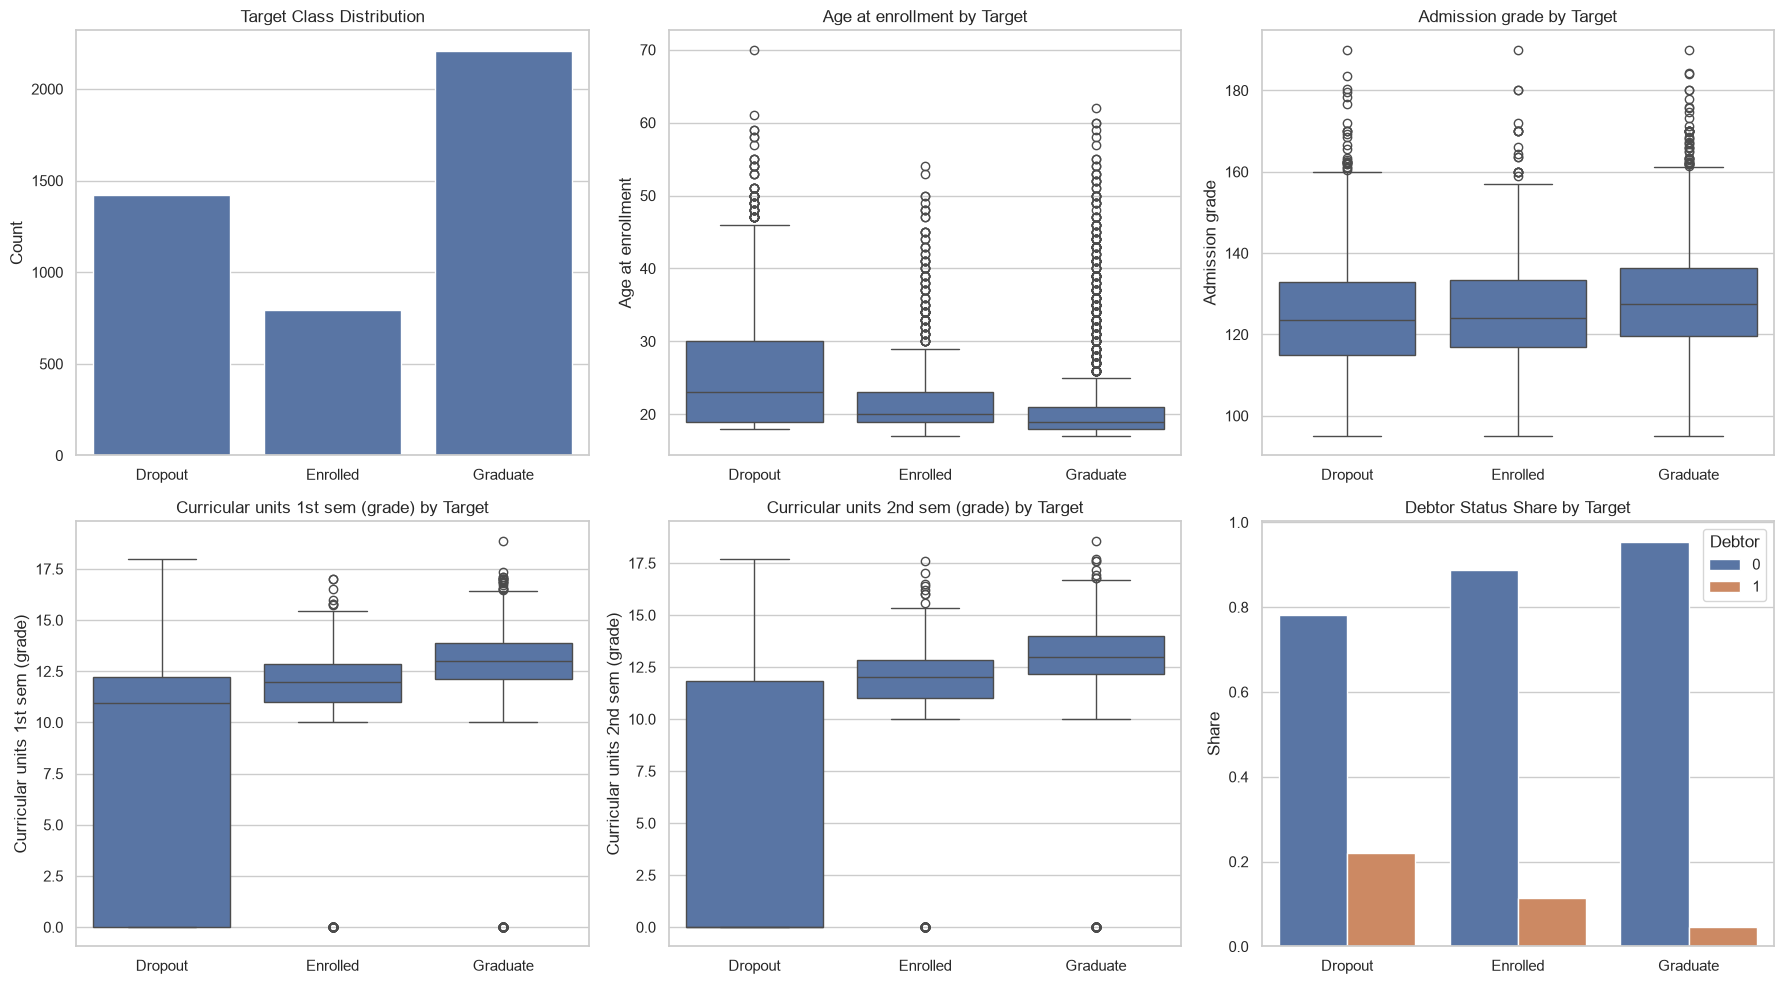

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df, x="target", order=target_order, ax=axes[0, 0])
axes[0, 0].set_title("Target Class Distribution")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Count")

plot_features = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
]
for ax, feature in zip(axes.flatten()[1:], plot_features):
    sns.boxplot(data=df, x="target", y=feature, order=target_order, ax=ax)
    ax.set_title(f"{feature} by Target")
    ax.set_xlabel("")

if "Debtor" in df.columns:
    debtor_rate = (
        pd.crosstab(df["target"], df["Debtor"], normalize="index")
        .stack()
        .rename("share")
        .reset_index()
    )
    sns.barplot(data=debtor_rate, x="target", y="share", hue="Debtor", order=target_order, ax=axes[1, 2])
    axes[1, 2].set_title("Debtor Status Share by Target")
    axes[1, 2].set_xlabel("")
    axes[1, 2].set_ylabel("Share")
else:
    axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


### 2.3 Phi-K Association Analysis

Phi-K handles mixed numeric and categorical variables better than a simple Pearson correlation matrix. It is used here to rank variables by association with the multiclass target and to guide feature selection and interpretation.


interval columns not set, guessing: ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation r

,phi_k_with_target
Curricular units 2nd sem (grade),0.774
Curricular units 1st sem (grade),0.701
Curricular units 2nd sem (approved),0.666
Curricular units 1st sem (approved),0.611
Curricular units 1st sem (evaluations),0.506
Application mode,0.439
Curricular units 2nd sem (evaluations),0.415
Age at enrollment,0.343
Curricular units 1st sem (enrolled),0.279
Tuition fees up to date,0.265


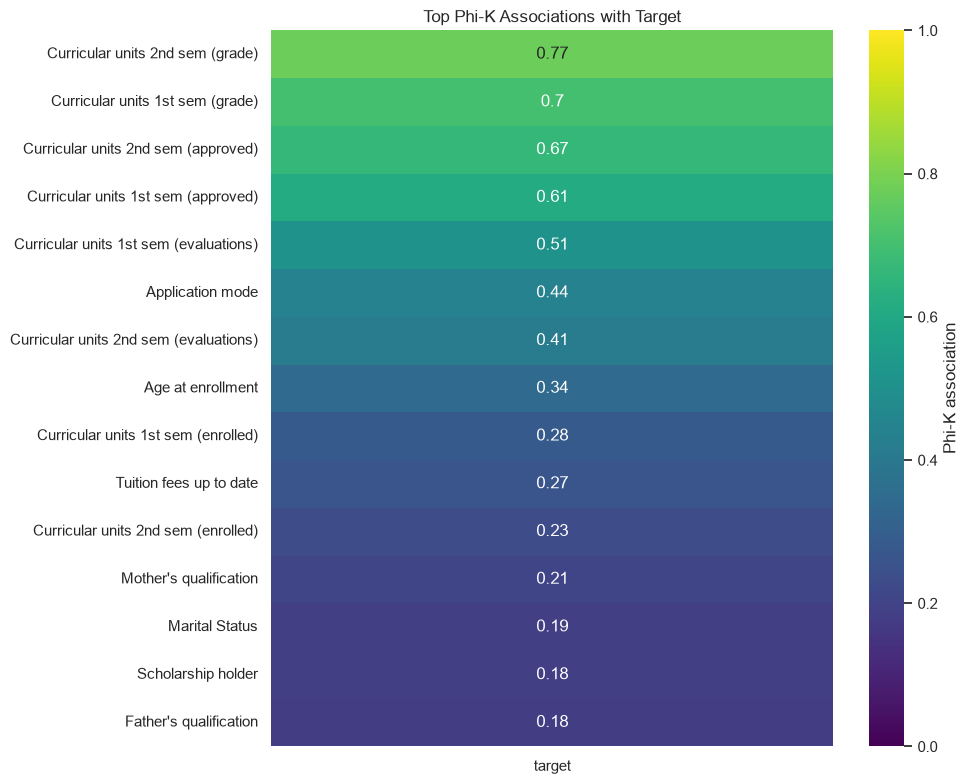

In [6]:
import phik

phik_matrix = df.phik_matrix()
target_associations = (
    phik_matrix["target"]
    .drop("target")
    .sort_values(ascending=False)
    .rename("phi_k_with_target")
    .to_frame()
)

display(target_associations.head(20).round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    phik_matrix.loc[target_associations.head(15).index, ["target"]],
    annot=True,
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Phi-K association"},
)
plt.title("Top Phi-K Associations with Target")
plt.tight_layout()
plt.show()


---

## 3. Initial EDA and Cleaning: Data Preparation and Feature Engineering

The UCI dataset is already well curated, but the cleaning workflow still checks missing values, duplicates, and outliers. Missing values are handled defensively so the notebook remains robust if the source data changes. Continuous outliers are clipped at the 1st and 99th percentiles; encoded categorical variables are not clipped because their integer values represent categories rather than measurement magnitude.


In [7]:
df_clean = df.drop_duplicates().copy()

if df_clean["target"].isna().any():
    df_clean = df_clean.dropna(subset=["target"])

for col in df_clean.columns.drop("target"):
    if df_clean[col].isna().any():
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode(dropna=True).iloc[0])

continuous_cols = [
    "Age at enrollment",
    "Previous qualification (grade)",
    "Admission grade",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]
continuous_cols = [c for c in continuous_cols if c in df_clean.columns]

outlier_rows = []
for col in continuous_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = int(((df_clean[col] < lower) | (df_clean[col] > upper)).sum())
    outlier_rows.append({"feature": col, "lower_iqr_bound": lower, "upper_iqr_bound": upper, "outlier_count": outlier_count})

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_summary.head(15).round(2))

for col in continuous_cols:
    lower, upper = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lower, upper)

print(f"Rows after duplicate removal and target cleanup: {df_clean.shape[0]}")
print(f"Remaining missing values: {int(df_clean.isna().sum().sum())}")


,feature,lower_iqr_bound,upper_iqr_bound,outlier_count
13,Curricular units 2nd sem (grade),6.88,17.21,877
7,Curricular units 1st sem (grade),7.40,17.00,726
3,Curricular units 1st sem (credited),0.00,0.00,577
9,Curricular units 2nd sem (credited),0.00,0.00,530
0,Age at enrollment,10.00,34.00,441
4,Curricular units 1st sem (enrolled),2.00,10.00,424
10,Curricular units 2nd sem (enrolled),2.00,10.00,369
8,Curricular units 1st sem (without evaluations),0.00,0.00,294
14,Curricular units 2nd sem (without evaluations),0.00,0.00,282
6,Curricular units 1st sem (approved),-1.50,10.50,180


Rows after duplicate removal and target cleanup: 4424
Remaining missing values: 0


### 3.1 Feature Engineering and Scaling

Four derived features are added from existing academic and financial fields:

- `approval_rate_s1`: first-semester approved units divided by enrolled units
- `approval_rate_s2`: second-semester approved units divided by enrolled units
- `grade_delta`: second-semester grade minus first-semester grade
- `financial_risk`: combined debtor, tuition, and scholarship signal

Preprocessing uses ordinal encoding for high-cardinality coded categories, one-hot encoding for lower-cardinality nominal categories, and numeric passthrough for continuous features. Scaling is applied inside the logistic regression pipeline because linear models are scale-sensitive; tree and boosting models do not require scaling for splits.


In [8]:
from dropout.features.engineer import OHE_COLS, ORDINAL_COLS, add_derived_features, build_preprocessor

DERIVED_FEATURES = ["approval_rate_s1", "approval_rate_s2", "grade_delta", "financial_risk"]

df_eng = add_derived_features(df_clean)
print(f"Original predictor count: {df_clean.shape[1] - 1}")
print(f"Engineered predictor count: {df_eng.shape[1] - 1}")
display(df_eng[DERIVED_FEATURES].describe().T.round(3))


Original predictor count: 36
Engineered predictor count: 40


,count,mean,std,min,25%,50%,75%,max
approval_rate_s1,4424.0,0.697,0.365,0.0,0.500,0.833,1.000,1.0
approval_rate_s2,4424.0,0.660,0.382,0.0,0.400,0.833,1.000,1.0
grade_delta,4424.0,-0.410,2.887,-16.0,-0.600,0.000,0.437,16.0
financial_risk,4424.0,0.328,0.244,0.0,0.333,0.333,0.333,1.0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df_eng["target"])
feature_cols = [c for c in df_eng.columns if c != "target"]
X = df_eng[feature_cols]

numeric_cols = [
    c for c in df_eng.columns
    if c not in ORDINAL_COLS + OHE_COLS + DERIVED_FEATURES + ["target"]
] + DERIVED_FEATURES

preprocessor = build_preprocessor(numeric_cols)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(f"Train rows before SMOTE: {X_train_proc.shape[0]}")
print(f"Validation rows: {X_val_proc.shape[0]}")
print(f"Test rows: {X_test_proc.shape[0]}")
print(f"Preprocessed feature count: {X_train_proc.shape[1]}")
print(f"Classes: {list(le.classes_)}")


Train rows before SMOTE: 2654
Validation rows: 885
Test rows: 885
Preprocessed feature count: 61
Classes: ['Dropout', 'Enrolled', 'Graduate']


### 3.2 Handling Class Imbalance Issues

The target distribution is imbalanced, with graduates usually forming the largest class and enrolled students the smallest. The workflow handles this in two ways:

- SMOTE is applied only to the training fold after preprocessing to avoid test-set leakage.
- Class-weighted estimators are used where supported, so minority classes have more influence during training.


In [10]:
from imblearn.over_sampling import SMOTE

before_smote = pd.Series(le.inverse_transform(y_train), name="class").value_counts().reindex(target_order)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

after_smote = pd.Series(le.inverse_transform(y_train_sm), name="class").value_counts().reindex(target_order)
imbalance_table = pd.concat(
    [before_smote.rename("before_smote"), after_smote.rename("after_smote")], axis=1
).fillna(0).astype(int)
display(imbalance_table)


,before_smote,after_smote
class,,
Dropout,853,1325
Enrolled,476,1325
Graduate,1325,1325


---

## 4. Feature Selection

Feature selection was based on three sources of evidence:

- EDA and Phi-K analysis identified academic progress, grades, financial standing, and age as target-associated variables.
- Domain reasoning supported retaining advising-actionable features such as tuition status, debtor status, scholarship status, and semester progress.
- A random forest importance model was used as a model-based check on the strongest transformed predictors.

Because the finalized dataset is moderate in width after preprocessing, the final training workflow retains the full curated feature set plus engineered features rather than aggressively dropping variables. The importance analysis below documents which features drive the model most strongly and supports the selected feature set.


,feature,importance
0,num__approval_rate_s2,0.1023
1,num__Curricular units 2nd sem (approved),0.0823
2,num__approval_rate_s1,0.0670
3,num__Curricular units 2nd sem (grade),0.0651
4,num__Curricular units 1st sem (approved),0.0510
5,num__Curricular units 1st sem (grade),0.0400
6,num__financial_risk,0.0377
7,num__Curricular units 1st sem (evaluations),0.0343
8,num__Curricular units 2nd sem (evaluations),0.0323
9,num__Age at enrollment,0.0303


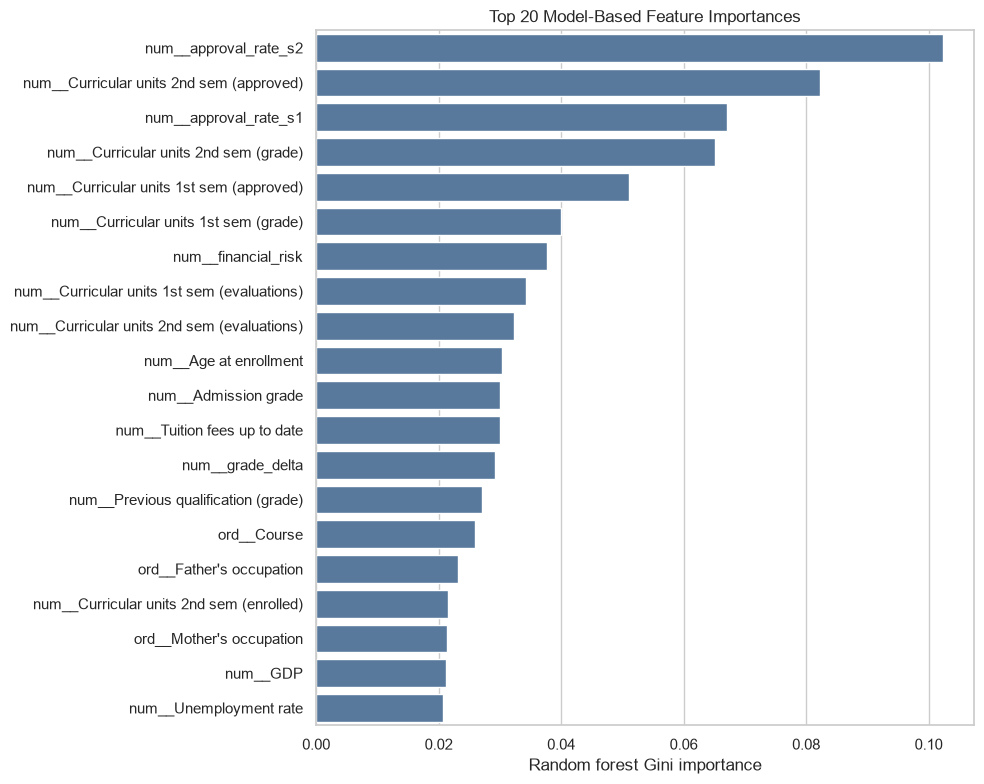

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_baseline.fit(X_train_sm, y_train_sm)

feature_importance = (
    pd.Series(rf_baseline.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .rename("importance")
)

top_features = feature_importance.head(20).rename_axis("feature").reset_index()
display(top_features.round(4))

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x="importance", y="feature", color="#4C78A8")
plt.title("Top 20 Model-Based Feature Importances")
plt.xlabel("Random forest Gini importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


---

## 5. Modeling with Logistic Regression, Random Forest, XGBoost, and LightGBM

The modeling strategy compares a simple linear baseline, bagging, boosting, and an ensemble stack:

- Logistic Regression: interpretable baseline with scaling and class weighting
- Random Forest: nonlinear bagging model with class weighting
- XGBoost: tuned gradient boosting model
- LightGBM: tuned gradient boosting model
- Stacking Ensemble: combines random forest, XGBoost, and LightGBM with a logistic regression meta-model

Optuna tunes the boosting models on the validation split. The final comparison uses the untouched test split.


In [12]:
import optuna
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 50

model_candidates = {}
model_rows = []


def score_model(name, fitted_model):
    val_pred = fitted_model.predict(X_val_proc)
    test_pred = fitted_model.predict(X_test_proc)
    return {
        "Model": name,
        "Validation_Macro_F1": f1_score(y_val, val_pred, average="macro"),
        "Test_Macro_F1": f1_score(y_test, test_pred, average="macro"),
        "Test_Balanced_Accuracy": balanced_accuracy_score(y_test, test_pred),
        "Test_Accuracy": accuracy_score(y_test, test_pred),
    }


In [13]:
lr = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
lr.fit(X_train_sm, y_train_sm)
model_candidates["Logistic Regression"] = lr
model_rows.append(score_model("Logistic Regression", lr))

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_sm, y_train_sm)
model_candidates["Random Forest"] = rf
model_rows.append(score_model("Random Forest", rf))

print("Finished Logistic Regression and Random Forest.")


Finished Logistic Regression and Random Forest.


In [14]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.30, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
    }
    candidate = xgb.XGBClassifier(
        **params,
        objective="multi:softprob",
        num_class=len(le.classes_),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    candidate.fit(X_train_sm, y_train_sm, eval_set=[(X_val_proc, y_val)], verbose=False)
    return f1_score(y_val, candidate.predict(X_val_proc), average="macro")

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb = xgb.XGBClassifier(
    **study_xgb.best_params,
    objective="multi:softprob",
    num_class=len(le.classes_),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
best_xgb.fit(X_train_sm, y_train_sm)
model_candidates["XGBoost"] = best_xgb
model_rows.append(score_model("XGBoost", best_xgb))

print(f"XGBoost best validation macro-F1: {study_xgb.best_value:.4f}")
print(study_xgb.best_params)


  0%|          | 0/50 [00:00<?, ?it/s]

XGBoost best validation macro-F1: 0.7279
{'n_estimators': 338, 'max_depth': 4, 'learning_rate': 0.010042672058252934, 'subsample': 0.7563331754648892, 'colsample_bytree': 0.8629235056131268}


In [15]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "num_leaves": trial.suggest_int("num_leaves", 20, 120),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.30, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 40),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
    }
    candidate = LGBMClassifier(
        **params,
        objective="multiclass",
        num_class=len(le.classes_),
        class_weight="balanced",
        verbose=-1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    candidate.fit(X_train_sm, y_train_sm, eval_set=[(X_val_proc, y_val)])
    return f1_score(y_val, candidate.predict(X_val_proc), average="macro")

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_lgb = LGBMClassifier(
    **study_lgb.best_params,
    objective="multiclass",
    num_class=len(le.classes_),
    class_weight="balanced",
    verbose=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_lgb.fit(X_train_sm, y_train_sm)
model_candidates["LightGBM"] = best_lgb
model_rows.append(score_model("LightGBM", best_lgb))

print(f"LightGBM best validation macro-F1: {study_lgb.best_value:.4f}")
print(study_lgb.best_params)


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM best validation macro-F1: 0.7245
{'n_estimators': 163, 'num_leaves': 98, 'learning_rate': 0.010237075389985535, 'min_child_samples': 31, 'subsample': 0.757971250655971}


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
stack = StackingClassifier(
    estimators=[("rf", rf), ("xgb", best_xgb), ("lgb", best_lgb)],
    final_estimator=LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1,
)
stack.fit(X_train_sm, y_train_sm)
model_candidates["Stacking Ensemble"] = stack
model_rows.append(score_model("Stacking Ensemble", stack))

print("Finished stacking ensemble.")


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Finished stacking ensemble.


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 5.1 Evaluation and Model Comparisons

The table and chart below compare the candidate models on macro-F1, balanced accuracy, and accuracy. Macro-F1 is the primary selection metric because the classes are imbalanced and each outcome class matters for advising decisions.


,Model,Validation_Macro_F1,Test_Macro_F1,Test_Balanced_Accuracy,Test_Accuracy
0,Stacking Ensemble,0.6862,0.7174,0.7138,0.7751
1,Random Forest,0.7073,0.7162,0.7129,0.7706
2,LightGBM,0.7245,0.7071,0.7040,0.7605
3,XGBoost,0.7279,0.7027,0.7015,0.7559
4,Logistic Regression,0.7020,0.6863,0.6948,0.7288


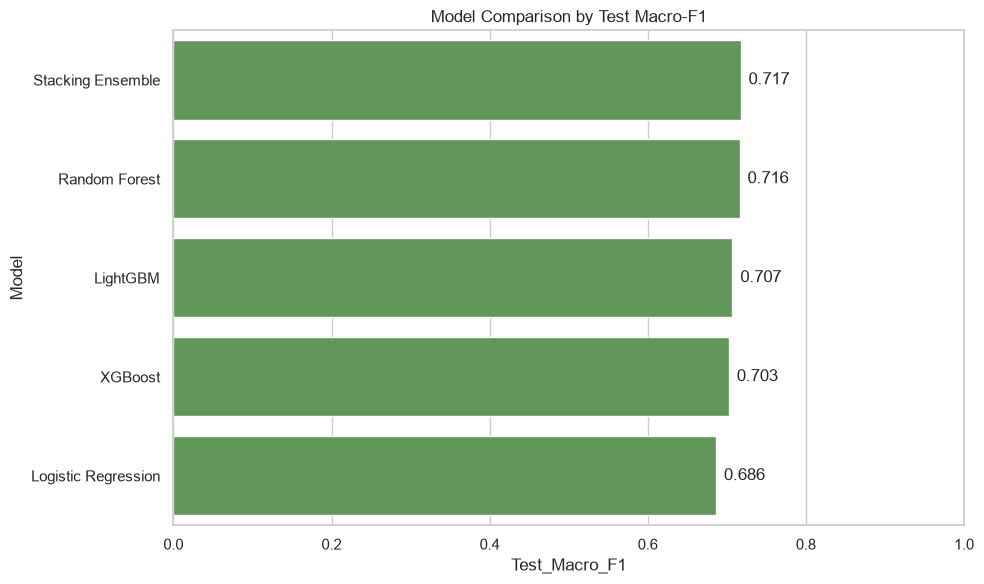

Selected model: Stacking Ensemble


In [17]:
results = pd.DataFrame(model_rows).sort_values("Test_Macro_F1", ascending=False).reset_index(drop=True)
display(results.round(4))

best_model_name = results.loc[0, "Model"]
best_model = model_candidates[best_model_name]
model = best_model

plt.figure(figsize=(10, 6))
sns.barplot(data=results, x="Test_Macro_F1", y="Model", color="#59A14F")
plt.title("Model Comparison by Test Macro-F1")
plt.xlim(0, 1)
for i, value in enumerate(results["Test_Macro_F1"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

print(f"Selected model: {best_model_name}")


---

## 6. Evaluation: Performance Measures, Results, and Conclusions

The final model is evaluated on the held-out test set using class-level precision, recall, F1-score, macro-F1, balanced accuracy, and a confusion matrix. The most important practical result is how reliably the model identifies dropout students without ignoring enrolled and graduate outcomes.


Best model: Stacking Ensemble

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.78      0.79      0.79       284
    Enrolled       0.55      0.48      0.51       159
    Graduate       0.84      0.87      0.86       442

    accuracy                           0.78       885
   macro avg       0.72      0.71      0.72       885
weighted avg       0.77      0.78      0.77       885



Macro one-vs-rest ROC-AUC: 0.8819


/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/manojpatra/miniforge3/envs/usd-aai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


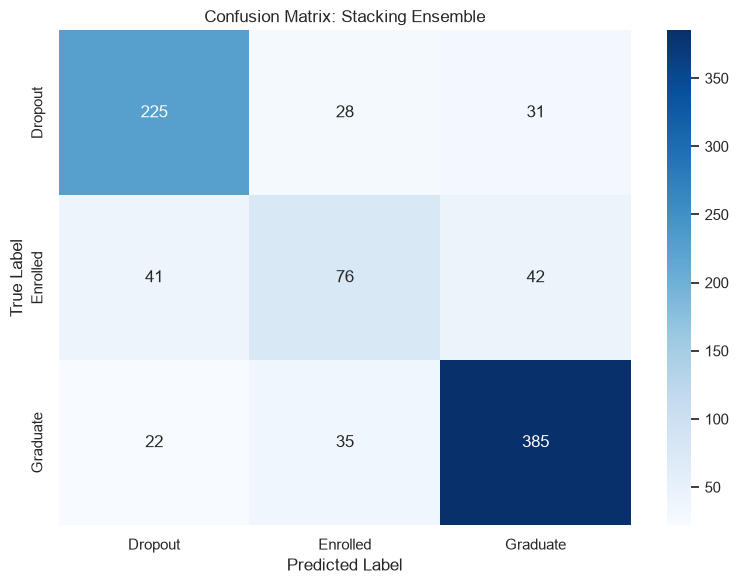

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_pred = best_model.predict(X_test_proc)
print(f"Best model: {best_model_name}")
print()
print("Classification Report:")
print(classification_report(y_test, best_pred, target_names=le.classes_))

if hasattr(best_model, "predict_proba"):
    best_proba = best_model.predict_proba(X_test_proc)
    macro_roc_auc = roc_auc_score(y_test, best_proba, multi_class="ovr", average="macro")
    print(f"Macro one-vs-rest ROC-AUC: {macro_roc_auc:.4f}")

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


### 6.1 Explainability with SHAP

SHAP is used to explain the tuned XGBoost model because it is a strong tree-based learner and SHAP's tree explainer is efficient for this model family. If the stacking model is selected as the final estimator, the XGBoost SHAP plot is still useful for explaining one of the major ensemble components.


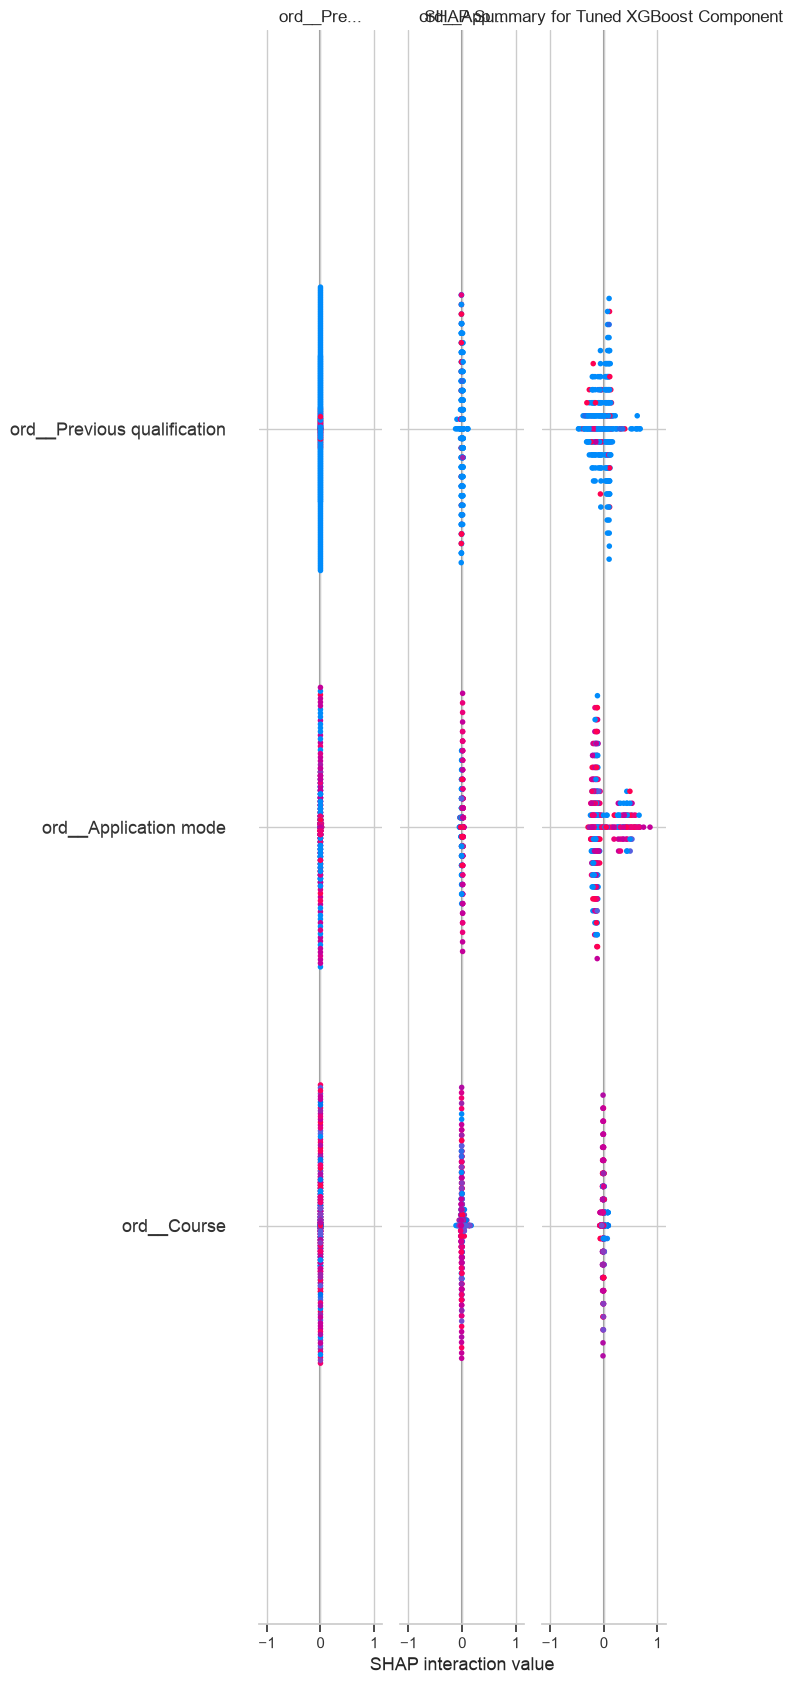

In [19]:
import shap

sample_size = min(300, X_test_proc.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(np.arange(X_test_proc.shape[0]), size=sample_size, replace=False)
X_shap = X_test_proc[sample_idx]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    class_names=list(le.classes_),
    max_display=20,
    show=False,
)
plt.title("SHAP Summary for Tuned XGBoost Component")
plt.tight_layout()
plt.show()


---

## 7. Deployment: FastAPI Service and Streamlit Application

The project includes an actual deployment path rather than only a hypothetical plan:

- `scripts/train.py` loads the finalized data, creates engineered features, trains the candidate models, selects the best model by macro-F1, and saves artifacts in `artifacts/`.
- `src/dropout/api/main.py` exposes a FastAPI application with `/health` and `/predict` endpoints.
- `src/dropout/ui/app.py` builds the Streamlit application for advisors. It collects the same student features used by the model, posts them to the API, and displays predicted outcome, dropout probability, risk tier, and class probabilities.

Recommended local deployment flow:

```bash
uv run python scripts/train.py
uv run uvicorn dropout.api.main:app --reload --port 8000
uv run streamlit run src/dropout/ui/app.py
```

In a production deployment, the API and UI would be containerized, protected behind authentication, monitored for latency and prediction drift, and retrained on a governed schedule. Advisor workflows should treat predictions as decision support, not as an automated decision system.


In [20]:
deployment_files = pd.DataFrame(
    [
        {"component": "Training entrypoint", "path": "scripts/train.py"},
        {"component": "FastAPI app", "path": "src/dropout/api/main.py"},
        {"component": "Prediction routes", "path": "src/dropout/api/routes.py"},
        {"component": "Streamlit application", "path": "src/dropout/ui/app.py"},
        {"component": "Feature engineering module", "path": "src/dropout/features/engineer.py"},
    ]
)
deployment_files["exists"] = deployment_files["path"].apply(lambda p: (PROJECT_ROOT / p).exists())
display(deployment_files)

artifact_files = pd.DataFrame(
    [
        {"artifact": "model.pkl", "path": PROJECT_ROOT / "artifacts" / "model.pkl"},
        {"artifact": "preprocessor.pkl", "path": PROJECT_ROOT / "artifacts" / "preprocessor.pkl"},
        {"artifact": "label_encoder.pkl", "path": PROJECT_ROOT / "artifacts" / "label_encoder.pkl"},
    ]
)
artifact_files["exists"] = artifact_files["path"].apply(lambda p: p.exists())
display(artifact_files.assign(path=artifact_files["path"].astype(str)))


,component,path,exists
0,Training entrypoint,scripts/train.py,True
1,FastAPI app,src/dropout/api/main.py,True
2,Prediction routes,src/dropout/api/routes.py,True
3,Streamlit application,src/dropout/ui/app.py,True
4,Feature engineering module,src/dropout/features/engineer.py,True


,artifact,path,exists
0,model.pkl,/Users/manojpatra/Documents/USD-APPLIEDAI-2025...,True
1,preprocessor.pkl,/Users/manojpatra/Documents/USD-APPLIEDAI-2025...,True
2,label_encoder.pkl,/Users/manojpatra/Documents/USD-APPLIEDAI-2025...,True


### 7.1 Building the Streamlit Application

The Streamlit app is designed for an academic advising workflow. It groups inputs into demographics, academic background, socioeconomic and financial factors, semester performance, and macroeconomic factors. After submission, it calls the FastAPI `/predict` endpoint and presents:

- Low, medium, or high dropout risk tier
- Dropout probability
- Predicted class label
- Probability for each class

This keeps the notebook analysis connected to a practical user interface that can support targeted student outreach.


In [21]:
import requests

health_url = "http://localhost:8000/health"
try:
    response = requests.get(health_url, timeout=5)
    print(f"API health response: {response.json()}")
except requests.exceptions.ConnectionError:
    print("FastAPI server is not currently running. Start it with:")
    print("  uv run uvicorn dropout.api.main:app --reload --port 8000")


API health response: {'status': 'ok'}


In [22]:
example_payload = {
    "marital_status": 1,
    "gender": 1,
    "age_at_enrollment": 20,
    "nationality": 1,
    "international": 0,
    "application_mode": 1,
    "application_order": 1,
    "course": 1,
    "daytime_evening_attendance": 1,
    "previous_qualification": 1,
    "previous_qualification_grade": 130.0,
    "admission_grade": 130.0,
    "displaced": 0,
    "mothers_qualification": 1,
    "fathers_qualification": 1,
    "mothers_occupation": 1,
    "fathers_occupation": 1,
    "educational_special_needs": 0,
    "debtor": 0,
    "tuition_fees_up_to_date": 1,
    "scholarship_holder": 0,
    "curricular_units_1st_sem_credited": 0,
    "curricular_units_1st_sem_enrolled": 6,
    "curricular_units_1st_sem_evaluations": 6,
    "curricular_units_1st_sem_approved": 6,
    "curricular_units_1st_sem_grade": 12.0,
    "curricular_units_1st_sem_without_evaluations": 0,
    "curricular_units_2nd_sem_credited": 0,
    "curricular_units_2nd_sem_enrolled": 6,
    "curricular_units_2nd_sem_evaluations": 6,
    "curricular_units_2nd_sem_approved": 6,
    "curricular_units_2nd_sem_grade": 13.0,
    "curricular_units_2nd_sem_without_evaluations": 0,
    "unemployment_rate": 10.0,
    "inflation_rate": 1.5,
    "gdp": 1.0,
}

try:
    response = requests.post("http://localhost:8000/predict", json=example_payload, timeout=10)
    response.raise_for_status()
    display(response.json())
except requests.exceptions.ConnectionError:
    print("FastAPI server is not running, so live prediction is skipped in this notebook run.")
except requests.exceptions.HTTPError as exc:
    print(f"API returned an error: {exc.response.text}")


{'predicted_outcome': 'Graduate',
 'dropout_probability': 0.0145,
 'risk_tier': 'Low',
 'class_probabilities': {'Dropout': 0.0145,
  'Enrolled': 0.0411,
  'Graduate': 0.9444}}

---

## 8. Discussion and Conclusions

The analysis addresses the original problem statement by building a reproducible model pipeline that predicts student outcomes and emphasizes dropout risk. EDA shows that semester progress, grades, financial indicators, and student background variables contain meaningful signal. The engineered approval-rate, grade-change, and financial-risk features make these patterns more direct for the models.

The recommended model is the candidate with the strongest held-out macro-F1 score, because macro-F1 balances performance across Dropout, Enrolled, and Graduate classes. For institutional use, predictions should be paired with advisor judgment and intervention policies such as financial aid outreach, academic tutoring, and early-semester check-ins.

Key recommendations:

- Use the model as an early warning tool, not a final decision-maker.
- Monitor class-level recall for Dropout students after deployment.
- Recalibrate and retrain the model when new cohorts or policy changes shift the data distribution.
- Use SHAP explanations to audit whether the model is relying on actionable academic and support variables rather than inappropriate proxies.


In [23]:
summary = {
    "dataset_rows": df.shape[0],
    "original_predictors": df.shape[1] - 1,
    "engineered_predictors": df_eng.shape[1] - 1,
    "preprocessed_features": X_train_proc.shape[1],
    "selected_model": best_model_name,
    "test_macro_f1": f1_score(y_test, best_pred, average="macro"),
    "classes": list(le.classes_),
}

for key, value in summary.items():
    print(f"{key}: {value}")


dataset_rows: 4424
original_predictors: 36
engineered_predictors: 40
preprocessed_features: 61
selected_model: Stacking Ensemble
test_macro_f1: 0.7174453187876008
classes: ['Dropout', 'Enrolled', 'Graduate']
